In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
import datetime
import time

DAYS_FOR_TRAIN = 10

In [55]:
class LSTM_Regression(nn.Module):
    """
        使用LSTM进行回归
        参数：
        - input_size: feature size
        - hidden_size: number of hidden units
        - output_size: number of output
        - num_layers: layers of LSTM to stack
    """
 
    def __init__(self, input_size, hidden_size, output_size=1, num_layers=2):
        super().__init__()
 
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers)
        self.fc = nn.Linear(hidden_size, output_size)
 
    def forward(self, _x):
        x, _ = self.lstm(_x)  # _x is input, size (seq_len, batch, input_size)
        s, b, h = x.shape
        x = x.view(s * b, h)
        x = self.fc(x)
        x = x.view(s, b, -1)  # 把形状改回来
        return x

In [56]:
def create_dataset(data, days_for_train=5) -> (np.array, np.array):
    """
        根据给定的序列data，生成数据集
        数据集分为输入和输出，每一个输入的长度为days_for_train，每一个输出的长度为1。
        也就是说用days_for_train天的数据，对应下一天的数据。
        若给定序列的长度为d，将输出长度为(d-days_for_train+1)个输入/输出对
    """
    dataset_x, dataset_y = [], []
    for i in range(len(data) - days_for_train):
        _x = data[i:(i + days_for_train)]
        dataset_x.append(_x)
        dataset_y.append(data[i + days_for_train])
    return (np.array(dataset_x), np.array(dataset_y))

In [57]:
t0 = time.time()
# df_sh = ts.get_k_data('sh', start='2019-01-01', end=datetime.datetime.now().strftime('%Y-%m-%d'))
# print(df_sh.shape)

data_close = pd.read_csv('train.csv')
data_close = data_close[data_close['symbol']=='ILMN']# @
data_close = data_close[['close']][:1000]  # 读取文件
data_close = data_close.astype('float32').values  # 转换数据类型
plt.plot(data_close)
plt.savefig('data.png', format='png', dpi=200)
plt.close()

# 将价格标准化到0~1
max_value = np.max(data_close)
min_value = np.min(data_close)
data_close = (data_close - min_value) / (max_value - min_value)

# dataset_x是形状为(样本数, 时间窗口大小)的二维数组，用于训练模型的输入
# dataset_y是形状为(样本数, )的一维数组，用于训练模型的输出。
dataset_x, dataset_y = create_dataset(data_close, DAYS_FOR_TRAIN)  # 分别是（1007,10,1）（1007,1）

# 划分训练集和测试集，70%作为训练集
train_size = int(len(dataset_x) * 0.7)

train_x = dataset_x[:train_size]
train_y = dataset_y[:train_size]

# 将数据改变形状，RNN 读入的数据维度是 (seq_size, batch_size, feature_size)
train_x = train_x.reshape(-1, 1, DAYS_FOR_TRAIN)
train_y = train_y.reshape(-1, 1, 1)

# 转为pytorch的tensor对象
train_x = torch.from_numpy(train_x)
train_y = torch.from_numpy(train_y)

model = LSTM_Regression(DAYS_FOR_TRAIN, 8, output_size=1, num_layers=2)  # 导入模型并设置模型的参数输入输出层、隐藏层等

model_total = sum([param.nelement() for param in model.parameters()])  # 计算模型参数
print("Number of model_total parameter: %.8fM" % (model_total / 1e6))

Number of model_total parameter: 0.00122500M


In [58]:
train_loss = []
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2, betas=(0.9, 0.999), eps=1e-08, weight_decay=0)
for i in range(300):# @
    out = model(train_x)
    loss = loss_function(out, train_y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    train_loss.append(loss.item())
    # 将训练过程的损失值写入文档保存，并在终端打印出来
    with open('log.txt', 'a+') as f:
        f.write('{} - {}\n'.format(i + 1, loss.item()))
    if (i + 1) % 1 == 0:
        print('Epoch: {}, Loss:{:.5f}'.format(i + 1, loss.item()))

Epoch: 1, Loss:0.31489
Epoch: 2, Loss:0.23293
Epoch: 3, Loss:0.16154
Epoch: 4, Loss:0.10055
Epoch: 5, Loss:0.05220
Epoch: 6, Loss:0.02240
Epoch: 7, Loss:0.01827
Epoch: 8, Loss:0.03648
Epoch: 9, Loss:0.05380
Epoch: 10, Loss:0.05741
Epoch: 11, Loss:0.05035
Epoch: 12, Loss:0.03910
Epoch: 13, Loss:0.02871
Epoch: 14, Loss:0.02176
Epoch: 15, Loss:0.01872
Epoch: 16, Loss:0.01872
Epoch: 17, Loss:0.02045
Epoch: 18, Loss:0.02269
Epoch: 19, Loss:0.02459
Epoch: 20, Loss:0.02568
Epoch: 21, Loss:0.02579
Epoch: 22, Loss:0.02497
Epoch: 23, Loss:0.02342
Epoch: 24, Loss:0.02141
Epoch: 25, Loss:0.01926
Epoch: 26, Loss:0.01725
Epoch: 27, Loss:0.01564
Epoch: 28, Loss:0.01456
Epoch: 29, Loss:0.01402
Epoch: 30, Loss:0.01392
Epoch: 31, Loss:0.01407
Epoch: 32, Loss:0.01421
Epoch: 33, Loss:0.01412
Epoch: 34, Loss:0.01368
Epoch: 35, Loss:0.01289
Epoch: 36, Loss:0.01184
Epoch: 37, Loss:0.01069
Epoch: 38, Loss:0.00963
Epoch: 39, Loss:0.00877
Epoch: 40, Loss:0.00817
Epoch: 41, Loss:0.00781
Epoch: 42, Loss:0.00758
E

In [59]:
# 画loss曲线
plt.figure()
plt.plot(train_loss, 'b', label='loss')
plt.title("Train_Loss_Curve")
plt.ylabel('train_loss')
plt.xlabel('epoch_num')
plt.savefig('loss.png', format='png', dpi=200)
plt.close()

# torch.save(model.state_dict(), 'model_params.pkl')  # 可以保存模型的参数供未来使用
t1 = time.time()
T = t1 - t0
print('The training time took %.2f' % (T / 60) + ' mins.')

tt0 = time.asctime(time.localtime(t0))
tt1 = time.asctime(time.localtime(t1))
print('The starting time was ', tt0)
print('The finishing time was ', tt1)

The training time took 0.34 mins.
The starting time was  Sat Jul 12 13:25:22 2025
The finishing time was  Sat Jul 12 13:25:42 2025


In [60]:

# for test
model = model.eval()  # 转换成评估模式
# model.load_state_dict(torch.load('model_params.pkl'))  # 读取参数

# 注意这里用的是全集 模型的输出长度会比原数据少DAYS_FOR_TRAIN 填充使长度相等再作图
dataset_x = dataset_x.reshape(-1, 1, DAYS_FOR_TRAIN)  # (seq_size, batch_size, feature_size)
dataset_x = torch.from_numpy(dataset_x)

pred_test = model(dataset_x)  # 全量训练集
# 的模型输出 (seq_size, batch_size, output_size)
pred_test = pred_test.view(-1).data.numpy()
pred_test = np.concatenate((np.zeros(DAYS_FOR_TRAIN), pred_test))  # 填充0 使长度相同
assert len(pred_test) == len(data_close)

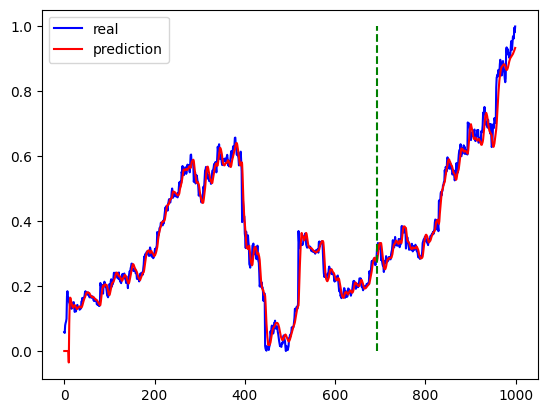

In [61]:
plt.plot(data_close, 'b', label='real')
plt.plot(pred_test, 'r', label='prediction')
plt.plot((train_size, train_size), (0, 1), 'g--')  # 分割线 左边是训练数据 右边是测试数据的输出
plt.legend(loc='best')
plt.savefig('result.png', format='png', dpi=200)
# plt.close()